**Los Angeles Crime Data - Exploratory Data Analysis (EDA)**

**Źródło danych - data.gov, dataset:  Crime Data from 2020 to Present**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Crime_Data_from_2020_to_Present.csv', sep = ',')


# pd.set_option('display.max_columns', None)

In [3]:
print(df.head())

       DR_NO               Date Rptd                DATE OCC  TIME OCC  AREA  \
0  211507896  04/11/2021 12:00:00 AM  11/07/2020 12:00:00 AM       845    15   
1  201516622  10/21/2020 12:00:00 AM  10/18/2020 12:00:00 AM      1845    15   
2  240913563  12/10/2024 12:00:00 AM  10/30/2020 12:00:00 AM      1240     9   
3  210704711  12/24/2020 12:00:00 AM  12/24/2020 12:00:00 AM      1310     7   
4  201418201  10/03/2020 12:00:00 AM  09/29/2020 12:00:00 AM      1830    14   

     AREA NAME  Rpt Dist No  Part 1-2  Crm Cd  \
0  N Hollywood         1502         2     354   
1  N Hollywood         1521         1     230   
2     Van Nuys          933         2     354   
3     Wilshire          782         1     331   
4      Pacific         1454         1     420   

                                         Crm Cd Desc  ... Status  Status Desc  \
0                                  THEFT OF IDENTITY  ...     IC  Invest Cont   
1     ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT  ...     

In [4]:
print(df.info)

<bound method DataFrame.info of              DR_NO               Date Rptd                DATE OCC  TIME OCC  \
0        211507896  04/11/2021 12:00:00 AM  11/07/2020 12:00:00 AM       845   
1        201516622  10/21/2020 12:00:00 AM  10/18/2020 12:00:00 AM      1845   
2        240913563  12/10/2024 12:00:00 AM  10/30/2020 12:00:00 AM      1240   
3        210704711  12/24/2020 12:00:00 AM  12/24/2020 12:00:00 AM      1310   
4        201418201  10/03/2020 12:00:00 AM  09/29/2020 12:00:00 AM      1830   
...            ...                     ...                     ...       ...   
1004986  252104112  02/02/2025 12:00:00 AM  02/02/2025 12:00:00 AM       130   
1004987  250404100  02/18/2025 12:00:00 AM  02/18/2025 12:00:00 AM      1000   
1004988  251304095  01/31/2025 12:00:00 AM  01/30/2025 12:00:00 AM      1554   
1004989  251704066  01/17/2025 12:00:00 AM  01/17/2025 12:00:00 AM      1600   
1004990  251904210  03/25/2025 12:00:00 AM  03/25/2025 12:00:00 AM      1235   

       

In [5]:
df.isnull().sum()

DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151619
Vict Age                0
Vict Sex           144644
Vict Descent       144656
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677744
Weapon Desc        677744
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935831
Crm Cd 3          1002677
Crm Cd 4          1004927
LOCATION                0
Cross Street       850755
LAT                     0
LON                     0
dtype: int64

In [6]:
df['Vict Sex'].value_counts()


Vict Sex
M    403879
F    358580
X     97773
H       114
-         1
Name: count, dtype: int64

In [7]:
df['Vict Descent'].value_counts()


Vict Descent
H    296404
W    201442
B    135816
X    106685
O     78005
A     21340
K      5990
F      4838
C      4631
J      1586
V      1195
I      1015
Z       577
P       288
U       221
D        91
L        77
G        74
S        58
-         2
Name: count, dtype: int64

In [8]:
df['Weapon Desc'].value_counts()


Weapon Desc
STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    174761
UNKNOWN WEAPON/OTHER WEAPON                        36390
VERBAL THREAT                                      23846
HAND GUN                                           20182
SEMI-AUTOMATIC PISTOL                               7267
                                                   ...  
MAC-11 SEMIAUTOMATIC ASSAULT WEAPON                    3
HECKLER & KOCH 91 SEMIAUTOMATIC ASSAULT RIFLE          2
MAC-10 SEMIAUTOMATIC ASSAULT WEAPON                    2
M-14 SEMIAUTOMATIC ASSAULT RIFLE                       2
M1-1 SEMIAUTOMATIC ASSAULT RIFLE                       1
Name: count, Length: 79, dtype: int64

In [9]:
print(f"Ilość początkowych uniklanych przestępstw: {df['Crm Cd Desc'].nunique()}")
print(f"Ilość dzielnic: {df['AREA NAME'].nunique()}")

Ilość początkowych uniklanych przestępstw: 140
Ilość dzielnic: 21


Przefiltrowanie popełnionych przestępstw - w domyślnym df'ie wystepuje 140 unikalnych, analize opieram na 20 najczęstszych przestępstwach

In [10]:
most_common_crimes = df['Crm Cd Desc'].value_counts().head(20).index
df_filtered = df[df['Crm Cd Desc'].isin(most_common_crimes)].copy()
print(f"Oryginalny rozmiar: {df.shape}")
print(f"Rozmiar po filtracji: {df_filtered.shape}")

Oryginalny rozmiar: (1004991, 28)
Rozmiar po filtracji: (867659, 28)


In [11]:
perc = df_filtered.shape[0]/df.shape[0]
print(f"Po filtracji top 20 przestępstw pozostało {df_filtered.shape[0]} z {df.shape[0]} rekordów, co stanowi {round(perc,2)}% oryginalnego datasetu")

Po filtracji top 20 przestępstw pozostało 867659 z 1004991 rekordów, co stanowi 0.86% oryginalnego datasetu


In [12]:
print(df_filtered[['AREA NAME', 'Crm Cd Desc']].isnull().sum())

AREA NAME      0
Crm Cd Desc    0
dtype: int64


W kluczowych kolumnach dla analizy (AREA NAME i Crm Cd Desc) nie ma wartości brakujących, nie trzeba uzupełniać/usuwać rekordów

In [13]:
crime_matrix = pd.crosstab(df_filtered['Crm Cd Desc'], df_filtered['AREA NAME'])
crime_matrix.head()

AREA NAME,77th Street,Central,Devonshire,Foothill,Harbor,Hollenbeck,Hollywood,Mission,N Hollywood,Newton,...,Olympic,Pacific,Rampart,Southeast,Southwest,Topanga,Van Nuys,West LA,West Valley,Wilshire
Crm Cd Desc,,,,,,,,,,,,,,,,,,,,,
"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",5921,4048,1329,1741,2342,2335,2736,1985,1973,3772,...,2674,2023,3100,4870,3636,1529,1628,777,1785,1683
BATTERY - SIMPLE ASSAULT,4707,6806,2696,2419,3157,3091,4482,2606,3433,4156,...,4383,3340,4135,3939,4528,2766,2852,2832,2752,3164
BRANDISH WEAPON,1452,1147,444,404,663,570,810,604,618,875,...,913,466,800,951,1105,455,428,309,520,529
BURGLARY,2170,2401,3552,1946,2340,1679,2615,1545,3725,2454,...,3099,4434,1846,1376,2118,3183,3184,4378,3558,3706
BURGLARY FROM VEHICLE,1890,9695,2573,1525,1733,1428,4334,1865,3614,2838,...,3446,3979,2845,1487,2177,2492,2764,3487,2756,3365


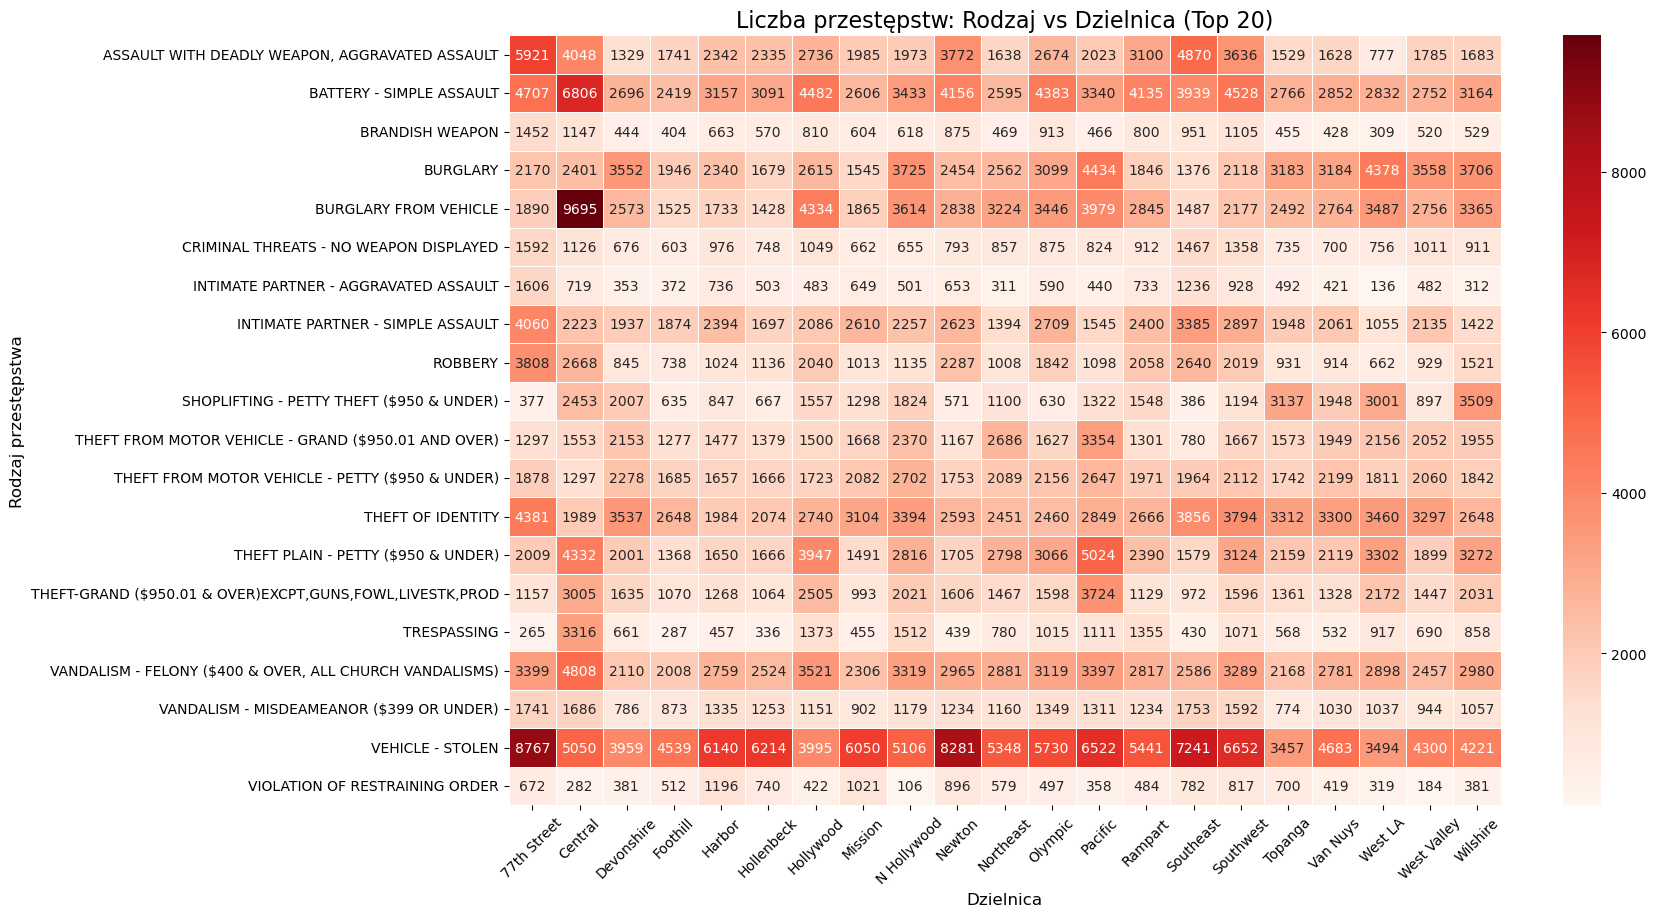

In [14]:
plt.figure(figsize=(16, 10))
sns.heatmap(
    crime_matrix,
    cmap = 'Reds',
    annot = True,
    fmt = 'd',
    linewidth = .5
)
plt.title('Liczba przestępstw: Rodzaj vs Dzielnica (Top 20)', fontsize=16)
plt.xlabel('Dzielnica', fontsize=12)
plt.xticks(rotation = 45)
plt.ylabel('Rodzaj przestępstwa', fontsize=12)
plt.show()

Heatmapa w prosty sposób pokazuje, które dzielnice są najbardziej oblegane jeżeli chodzi o przestępstwa, oraz które przestępstwa są najczęściej
popełniane. Najczęściej popełnianym przestępstwem w danej dzielnicy jest włamanie do pojazdu w dzielnicy Central (prawie bordowy kolor), które wystąpiło aż 9695 razy. 

Jednak najpopularniejszym przestępstwem w prawie wszystkich dzielnicach jest kradzież samochodu, która jest najczęstszym przestępstwem w aż 18 dzielnicach (na 21 wszystkich), często z dwukrotną przewagą ilości nad innymi przestępstwami.  

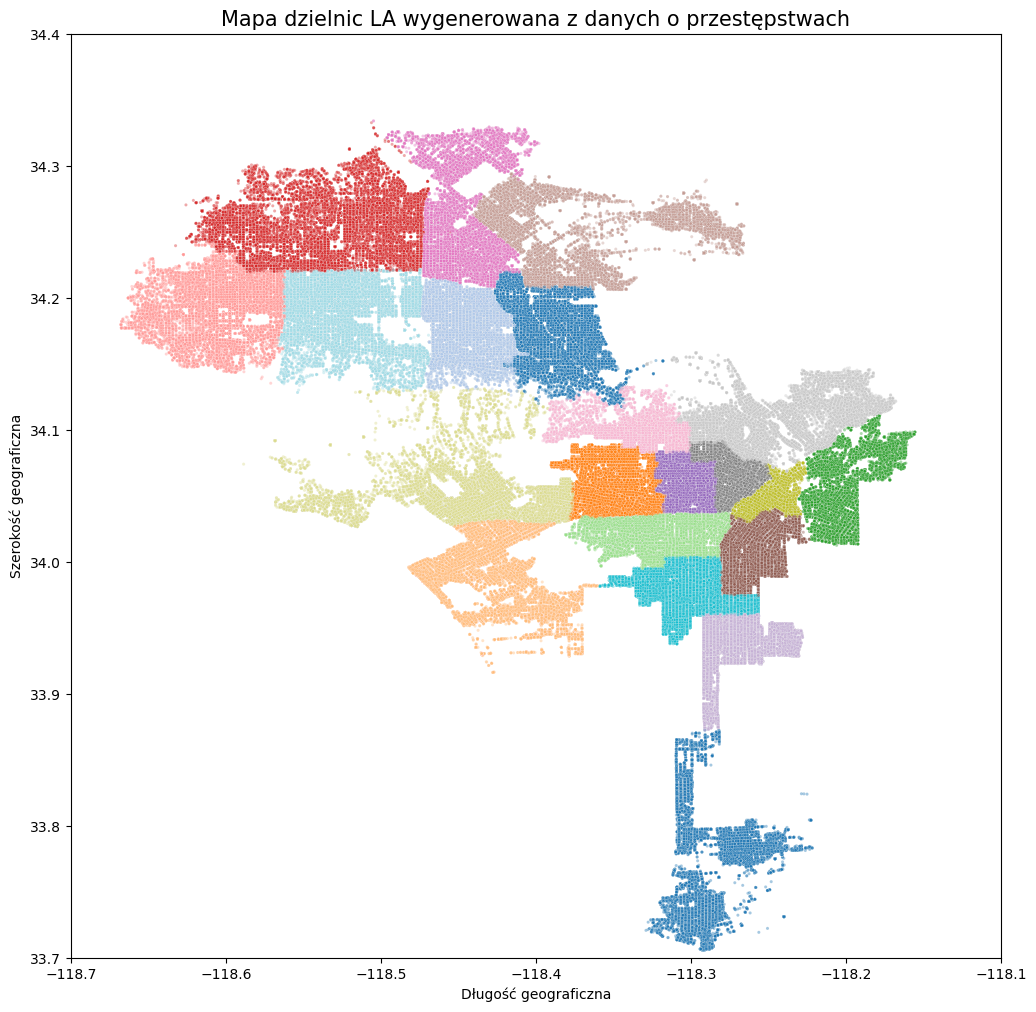

In [15]:
df_clean = df_filtered.copy()
df_clean = df_clean[(df_clean['LAT'] != 0) & (df_clean['LON'] != 0)]


plt.figure(figsize=(12, 12))

sns.scatterplot(x='LON', y='LAT', 
                data=df_clean,  
                hue='AREA NAME', # kazda dzielnica jest kolorowana na inny kolor
                alpha=0.4,      
                s=5,         
                palette='tab20', 
                legend=False)   

plt.title('Mapa dzielnic LA wygenerowana z danych o przestępstwach', fontsize=15)
plt.xlabel('Długość geograficzna')
plt.ylabel('Szerokość geograficzna')
plt.xlim(-118.7, -118.1)
plt.ylim(33.7, 34.4)

plt.show()

Wykres ukazuje nam mape dzielnic LA według podziału policyjnego. Obszar podzielony jest na kilka "rejonów": 
Górny blok (róże, błękity): To San Fernando Valley (Dolina). Jest oddzielona od reszty miasta.

Pusta przestrzeń w środku: Biała wyrwa oddzielająca górę od dołu to Góry Santa Monica. Nie ma tam ulic, posterunków i prawie nie ma przestępstw.

Gęste centrum (prawa strona, środek): Tam, gdzie kropki zlewają się w jednolitą plamę, to ścisłe centrum (Downtown/Central), zagęszczenie przestępstw jest na tyle duże, że nie widać prześwitów.

Długi "ogon" na dole: Niebieski pasek ciągnący się na samo południe to słynny Harbor Gateway. Los Angeles kupiło kiedyś ten wąski pas ziemi tylko po to, żeby połączyć miasto z portem (San Pedro – kępa kropek na samym dole).

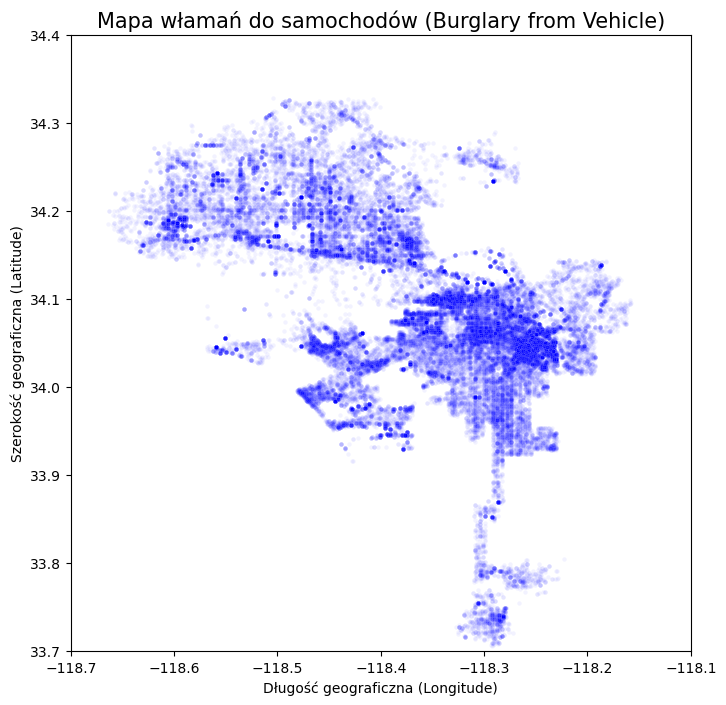

In [16]:
map_data = df_clean[df_clean['Crm Cd Desc'] == 'BURGLARY FROM VEHICLE']

plt.figure(figsize=(8, 8))

sns.scatterplot(x='LON', y='LAT', 
                data=map_data, 
                alpha=0.05,  
                s=10,       
                color='blue')

plt.title('Mapa włamań do samochodów (Burglary from Vehicle)', fontsize=15)
plt.xlabel('Długość geograficzna (Longitude)')
plt.ylabel('Szerokość geograficzna (Latitude)')
plt.xlim(-118.7, -118.1) 
plt.ylim(33.7, 34.4)

plt.show()

Na wykresie widać ciemnoniebieski obszar po prawej stronie w środku. Jest to Downtown (obszar Central), który na heatmapie świecił się na czerwono z liczbą 9695 włamań. Dziura (pusty obszar) w środku mapy po lewej stronie to Góry Santa Monica (Hollywood Hills). Nikt tam nie parkuje, są tylko wille więc nie ma włamań do aut.

Kropki układają się w linie proste. To pokazuje, że dane są precyzyjne – włamania dzieją się na konkretnych ulicach, które w USA są budowane pod kątem prostym.

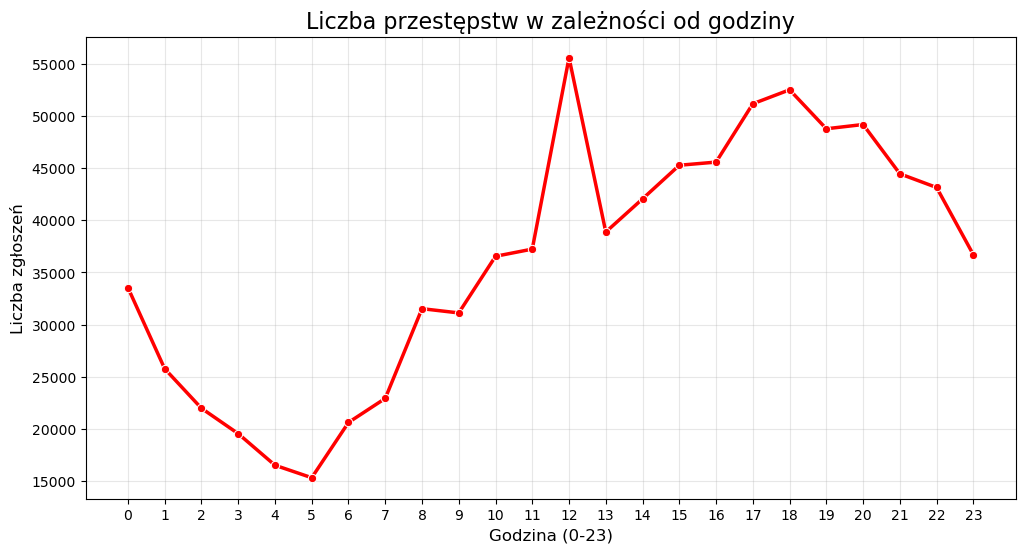

In [17]:
df_clean['Hour'] = df_clean['TIME OCC'] // 100

hourly_crime = df_clean.groupby('Hour').size()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_crime, marker='o', color='red', linewidth=2.5)

plt.title('Liczba przestępstw w zależności od godziny', fontsize=16)
plt.xlabel('Godzina (0-23)', fontsize=12)
plt.ylabel('Liczba zgłoszeń', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24)) 

plt.show()

W wykresie liczby przestępstw w zależności od godziny prawdopodobnie występuje anomalia pry godzinie 12, przy której jest nieregularny
szpic, wskazujący na bardzo zwiększoną liczbę przestępstw w porównaniu do godzin sąsiadujących (11,13). Przy spisywaniu raportu przez 
służby, w momencie gdy osoba zgłaszająca nie znała dokładnej godziny prawdopodobnie została domyślnie wpisywana godzina 12. Prawdziwy szczyt
przestępstw występuje o godzinie 17-18. Zaczyna się wtedy ściemniać, ludzie wracają z pracy, samochody są pozostawiane np. przy sklepach,
ulice są tłoczne, zmęczenie po całym dniu jest zwiększone, przez co ostrożność spada. Najmniej przestępstw występuje o godzinie 4-5 w nocy, kiedy
ludzie śpią, występuje mały ruch na ulicach, dużo samochodów jest zaparkowanych w garażach. 

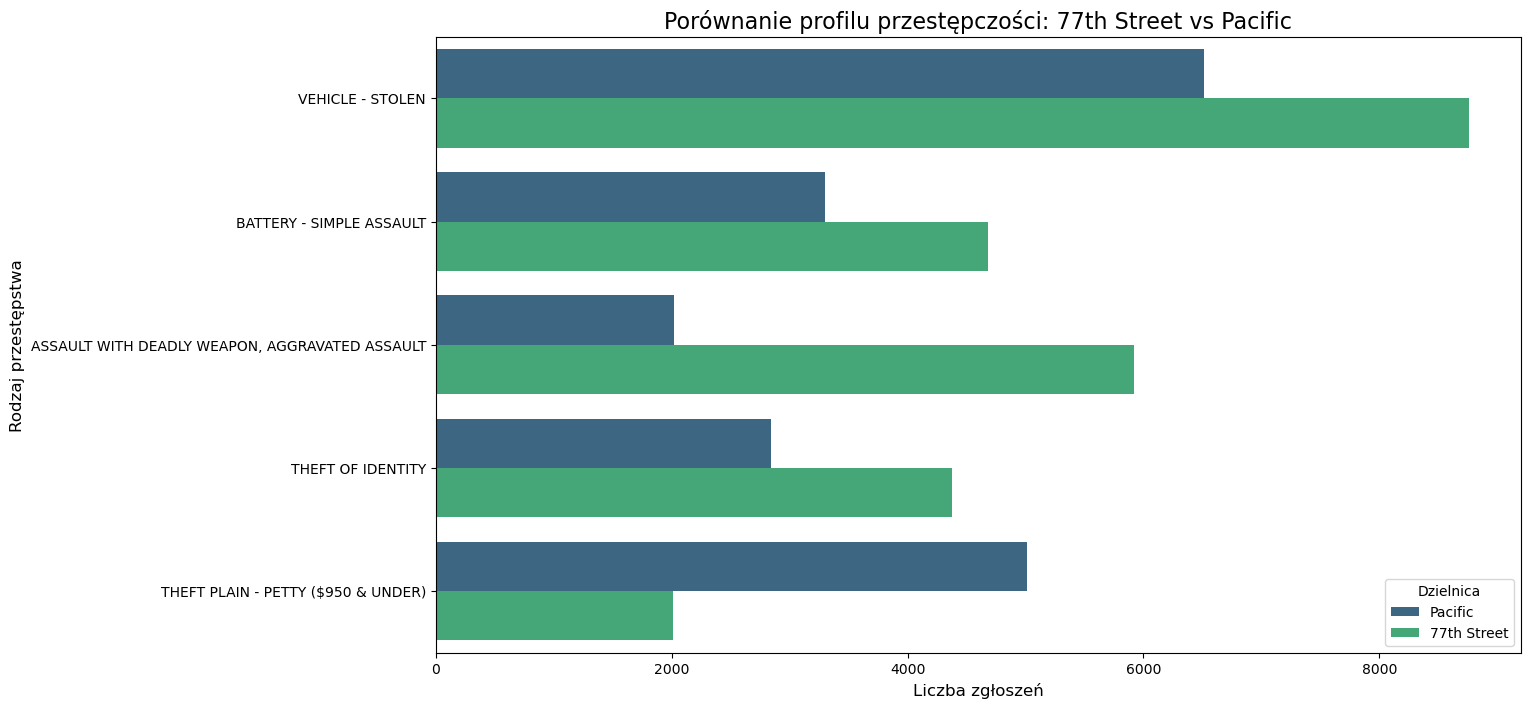

In [18]:
area_1 = '77th Street' # dzielica uznawana za "trudna"
area_2 = 'Pacific' # dzielnica turystyczna, bogatsza
 
df_compare = df_clean[df_clean['AREA NAME'].isin([area_1, area_2])].copy()

top_5_compare = df_compare['Crm Cd Desc'].value_counts().head(5).index

df_compare_final = df_compare[df_compare['Crm Cd Desc'].isin(top_5_compare)]

plt.figure(figsize=(14, 8))

sns.countplot(data=df_compare_final, 
              y='Crm Cd Desc',     
              hue='AREA NAME',     
              palette='viridis',    
              order=top_5_compare)

plt.title(f'Porównanie profilu przestępczości: {area_1} vs {area_2}', fontsize=16)
plt.xlabel('Liczba zgłoszeń', fontsize=12)
plt.ylabel('Rodzaj przestępstwa', fontsize=12)
plt.legend(title='Dzielnica')

plt.show()

**Porównanie 2 dzielnic, 77th street powszechnie uznawaną za "gorszą/cięższą" oraz Pacific, turystyczna i bogatsza**

Przestępczość brutalna (Assault with Deadly Weapon): Zielony słupek dla 77th Street jest 3 razy wyższy niż niebieski dla Pacific. Wskazuje to na to, że w 77th Street mamy do czynienia z dużo poważniejszym zagrożeniem dla życia i zdrowia. Dzielnica ta jest znana z aktywności "gangów" które mają silną tożsamość lokalną. 

Drobne kradzieże (Theft Plain - Petty): W Pacific (dzielnica nadmorska, Venice Beach, Santa Monica itp.) króluje drobna kradzież (do 950$). To typowe dla rejonów turystycznych przestępczość "okazji" – kradzieże telefonów na plaży, torebek w kawiarniach, rzeczy ze sklepów. 

Kradzieże samochodów (Vehicle Stolen): To problem obu dzielnic, ale 77th Street zdecydowanie przoduje.


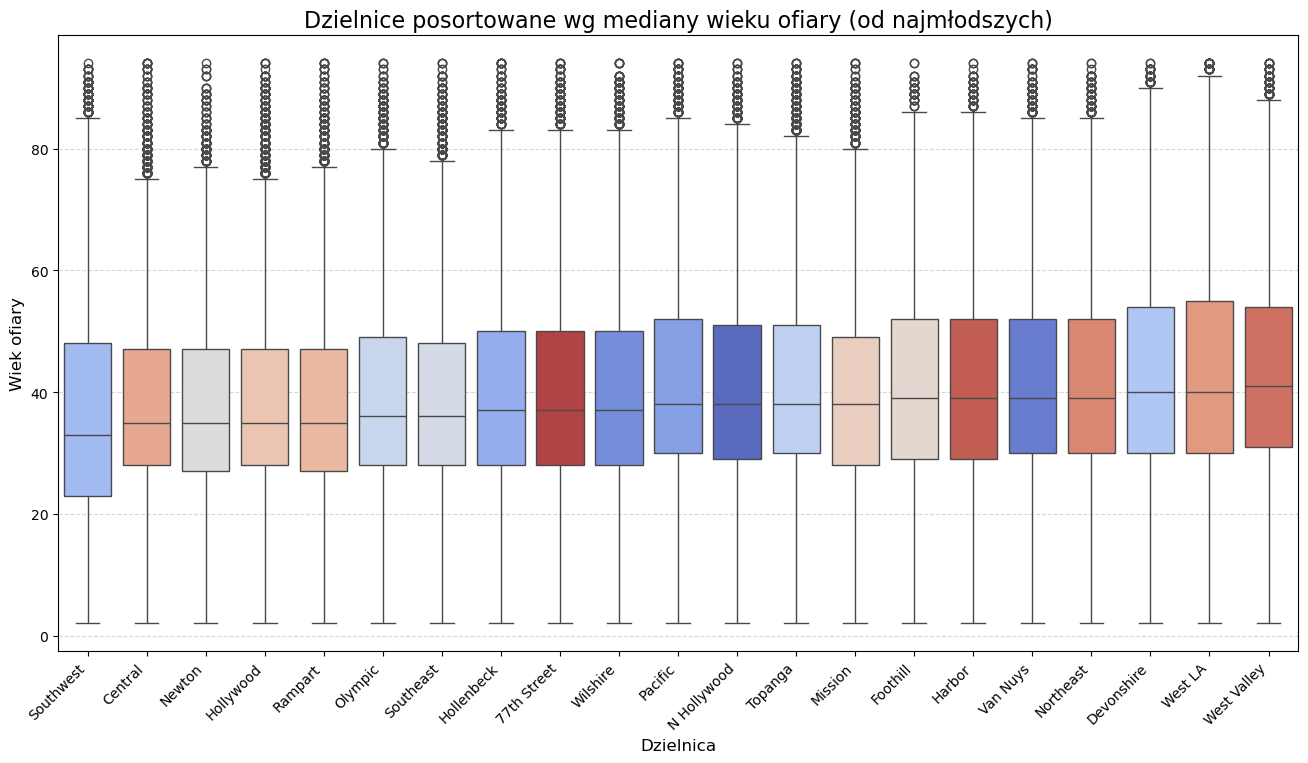

In [19]:
plt.figure(figsize=(16, 8))

age_data = df_clean[(df_clean['Vict Age'] > 0) & (df_clean['Vict Age'] < 95)].copy()

sorted_order = age_data.groupby('AREA NAME')['Vict Age'].median().sort_values().index.tolist()

sns.boxplot(x='AREA NAME', 
            y='Vict Age', 
            data=age_data,
            order=sorted_order,   
            hue='AREA NAME',      
            palette='coolwarm',
            legend=False)         

plt.title('Dzielnice posortowane wg mediany wieku ofiary (od najmłodszych)', fontsize=16)
plt.xlabel('Dzielnica', fontsize=12)
plt.ylabel('Wiek ofiary', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Box plot od lewej storny ukazuje dzielnice, w których średnia wieku jest najmniejsza, zaczynając od Southwest, gdzie mediana wychodzi około 32 lat, podczas gdy w innych dzielnicach jest bliżej 40. 

Dzielnica Southwest w Los Angeles obejmuje tereny wokół USC (University of Southern California) oraz Exposition Park, przez co średnia wieku jest tam zdecydowanie niższa, co potwierdza wykres.

W West LA oraz West Valley pudełka są wyżej, co wskazuje na większą medianę. Są to bogatsze, spokojniejsze dzielnice, gdzie średnia wieku ofiar jest wyższa (ok. 40-42 lata).

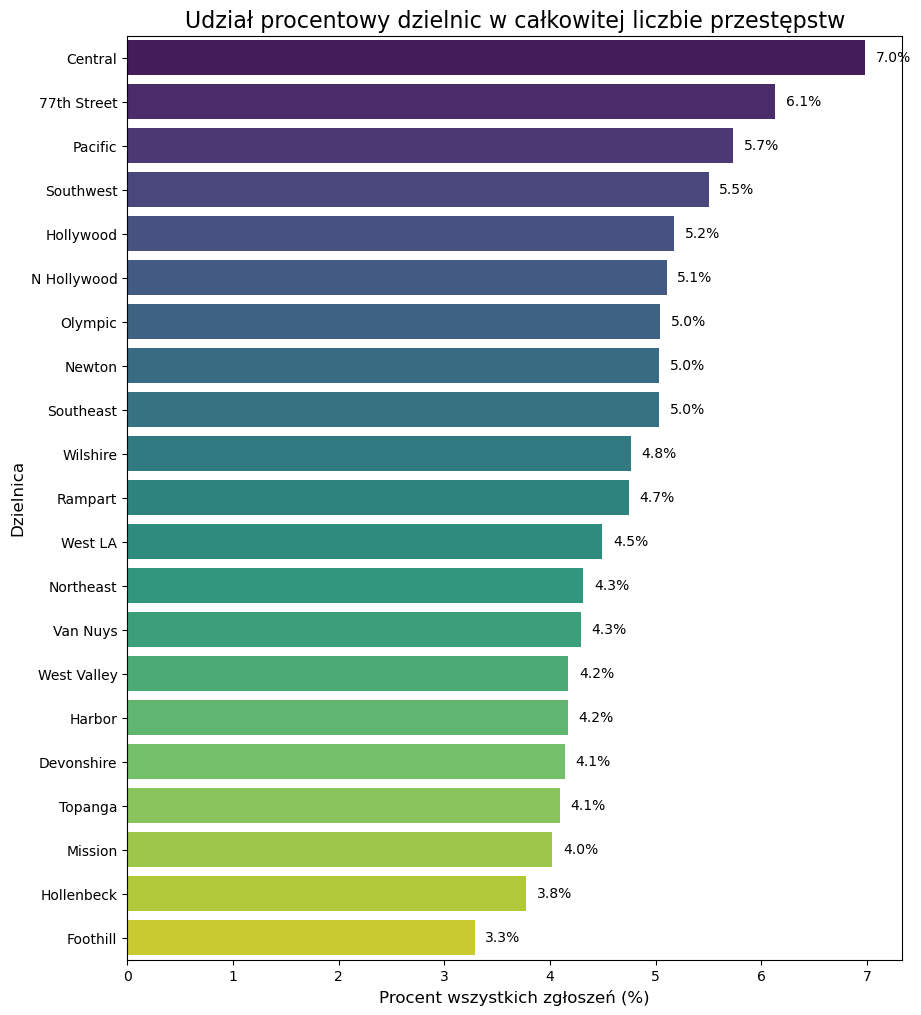

In [20]:
crime_counts = df_clean['AREA NAME'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 12))

sns.barplot(x=crime_counts.values, 
            y=crime_counts.index, 
            hue=crime_counts.index,
            palette='viridis',
            legend=False)

plt.title('Udział procentowy dzielnic w całkowitej liczbie przestępstw', fontsize=16)
plt.xlabel('Procent wszystkich zgłoszeń (%)', fontsize=12)
plt.ylabel('Dzielnica', fontsize=12)

for index, value in enumerate(crime_counts.values):
    plt.text(value + 0.1, index, f'{value:.1f}%', va='center')

plt.show()

**WNIOSKI**

Los Angeles zmaga się przede wszystkim z przestępczością przeciwko mieniu, a w szczególności z przestępczością samochodową.

    Dominujące typy: Trzy najczęstsze kategorie (Kradzież samochodu, Włamanie do samochodu, Kradzież tożsamości) stanowią znaczną część wszystkich zgłoszeń.

    Specyfika miasta: Vehicle - Stolen (Kradzież auta) jest problemem systemowym występującym masowo w niemal każdej dzielnicy, co potwierdza Heatmapa. Samochód jest w LA dobrem powszechnym, ale też głównym celem przestępców.
    


Geografia Zdarzeń: "Central" jako epicentrum

Analiza przestrzenna (mapy oraz ranking dzielnic) wskazuje na wyraźną koncentrację zdarzeń.

    Najniebezpieczniejszy rewir: Dzielnica Central odpowiada za aż 7.0% wszystkich zgłoszeń, co jest najwyższym wynikiem w mieście. Wynika to prawdopodobnie z dużego zagęszczenia ludności, biur i turystów (Downtown LA).

    Topografia: Mapa punktowa precyzyjnie odwzorowała układ miasta, ujawniając "martwe strefy" w rejonie Gór Santa Monica, gdzie przestępczość praktycznie nie występuje.

    Jakość danych: Wykres mapy z podziałem na kolory potwierdził wysoką jakość danych geolokalizacyjnych – granice rewirów policyjnych są ostre i nie nakładają się na siebie.
    


Profil Dzielnic: Biedne vs Bogate (77th Street vs Pacific)

Porównanie dwóch skrajnych dzielnic ujawniło drastyczne różnice w "profilu przestępcy":

    77th Street (Południowe LA): Dominuje tu przestępczość cięższa i brutalna. Liczba napadów z bronią (Assault with Deadly Weapon) jest tu 3-krotnie wyższa niż w dzielnicach nadmorskich. Kradzieże aut są tu również najczęstsze.

    Pacific (Wybrzeże/Turystyka): Przestępczość ma tu charakter "okazjonalny". Dominują drobne kradzieże (Petty Theft), kradzieże torebek czy rzeczy pozostawionych na plaży/w kawiarniach.



Analiza Czasowa: Kiedy uważać?

    Najbezpieczniejsza pora: Godzina 5:00 rano to moment najniższej aktywności przestępczej.

    Szczyt zagrożenia: Przestępczość rośnie liniowo w ciągu dnia, osiągając apogeum w godzinach wieczornych (17:00 – 19:00). Pokrywa się to z powrotami z pracy, korkami i zwiększonym ruchem ulicznym.

    Anomalia danych: Zaobserwowano nienaturalny "pik" zgłoszeń o godzinie 12:00, co zidentyfikowano jako artefakt danych (domyślna godzina wpisywana przy braku dokładnych informacji).



Demografia Ofiar (Box Plot)

Analiza wieku ofiar (wykres pudełkowy) wykazała interesującą anomalię w dzielnicy Southwest. Mediana wieku ofiar jest tam o ok. 10 lat niższa niż w reszcie miasta (ok. 30 lat vs 40 lat).

    Wniosek: Dzielnica ta obejmuje tereny uniwersyteckie (USC), co sprawia, że ofiarami przestępstw padają tam głównie studenci i młodzi dorośli.